Finite N-Player Centipede Games (8p, 2p8r), CDF Approach for heatmap -- same defection rate calc as OG heatmaps (fig 6)

Data files not included in repo:
- OLDdata_paper_player.csv 
- OLDdata_paper_group.csv
- NEWprocessed.rds

 contact to request. 

In [ ]:
# OLD data setup

library(tidyverse)
library(patchwork)

pct <- function(num, den, digits = 1) {
  round(100 * num / den, digits)
}

compute_node_stats <- function(df, n_rounds) {
  last_node <- n_rounds - 1L
  penultimate_node <- n_rounds - 2L

  list(
    n_games = nrow(df),
    defect_node1 = sum(df$end_cat == 1),
    reach_last = sum(df$coop >= last_node),
    defect_last = sum(df$coop == last_node),
    reach_penultimate = sum(df$coop >= penultimate_node),
    defect_penultimate = sum(df$coop == penultimate_node)
  )
}

paper_player <- read.csv("OLDdata_paper_player.csv")
paper_group  <- read.csv("OLDdata_paper_group.csv")

# Restrict to groups without any timeout.
# If end is NA, play reached the final node (coded as coop + 1).
gnt_all <- paper_group |>
  filter(grouptimeout == 0) |>
  mutate(end_cat = as.integer(if_else(is.na(end), coop + 1L, as.integer(end))))

gnt_8p   <- gnt_all |> filter(treatment == "8P")
gnt_2p8r <- gnt_all |> filter(treatment == "2P8R")
gnt_hs   <- gnt_all |> filter(treatment == "8P-HS")
gnt_lr   <- gnt_all |> filter(treatment == "8P-LR")
gnt_4p   <- gnt_all |> filter(treatment == "4P")

stats_8p <- compute_node_stats(gnt_8p, n_rounds = 8L)
stats_2p8r <- compute_node_stats(gnt_2p8r, n_rounds = 8L)


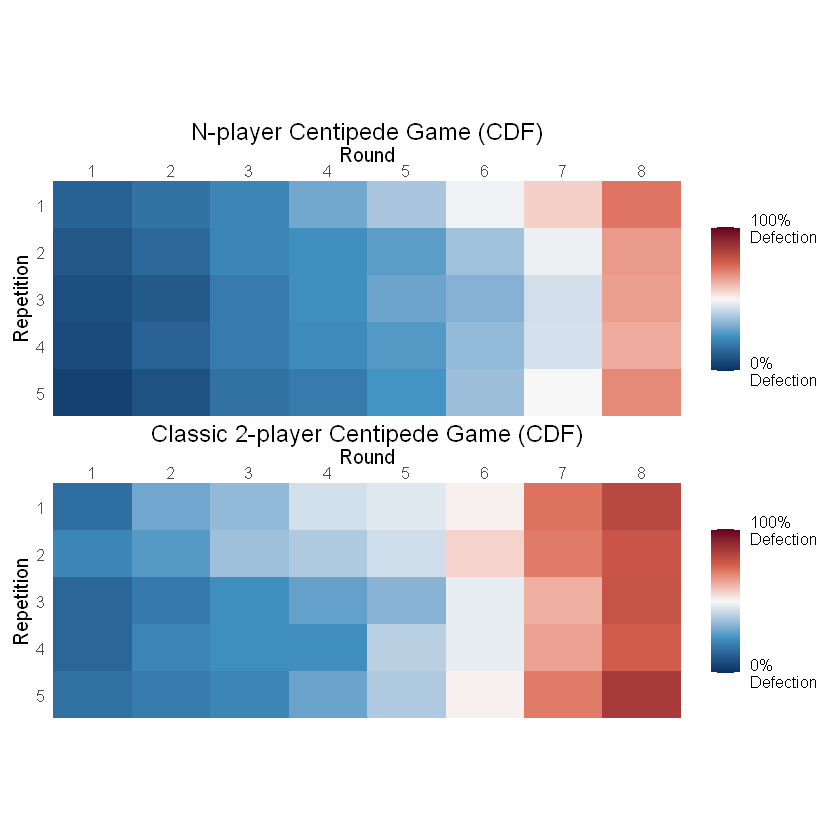

In [7]:
# =============================================================================
# =============================================================================
# 8.  XX-salin: OLD heatmap, cdf
# =============================================================================
# =============================================================================

##### CDF Approach
# cumulative proportion of defect by round N, by repetition and node

compute_heatmap_cdf <- function(df, n_rounds = 8) {
  expand.grid(repetition =1:5, node = 1:n_rounds) |>
    as_tibble() |>
    rowwise() |>
    mutate(
      total_games = sum(df$repetition == repetition),
      stopped_before = sum(df$repetition == repetition & df$end_cat <= node),
      defect_rate_cdf = if_else(total_games > 0, stopped_before / total_games, NA_real_)
    ) |>
    ungroup()
}

heatmap_8p_cdf <- compute_heatmap_cdf(gnt_8p, n_rounds = 8)
heatmap_2p8r_cdf <- compute_heatmap_cdf(gnt_2p8r, n_rounds = 8)

# plotting heatmaps 

plot_heatmap_cdf <- function(data, title) {
  ggplot(data, aes(x = node, y = repetition, fill = defect_rate_cdf)) +
    geom_tile(linewidth = 0) +
    scale_fill_gradientn(
      colors  = rev(RColorBrewer::brewer.pal(11, "RdBu"))[c(1, 3, 6, 9, 11)],
      limits  = c(0, 1),
      breaks  = c(0, 1),
      labels  = c("0%\nDefection", "100%\nDefection"),
      name    = NULL
    ) +
    scale_x_continuous(breaks = 1:8, position = "top", expand = c(0,0)) +
    scale_y_continuous(breaks = 1:5, trans = "reverse", expand = c(0,0)) +
    labs(title = title, x = "Round", y = "Repetition") +
    coord_fixed(ratio = 0.6) +
    theme_minimal(base_size = 12) +
    theme(
      panel.grid      = element_blank(),
      plot.title      = element_text(hjust = 0.5, margin = margin(b=0)),
      legend.position = "right",
      axis.title.x.top = element_text(margin = margin(b=1, t = 0)),
      axis.text.x.top = element_text(margin = margin(b=2)),
      plot.margin = margin(2,2,2,2)
    )
}

p1cdf <- plot_heatmap_cdf(heatmap_8p_cdf,   "N-player Centipede Game (CDF)")
p2cdf <- plot_heatmap_cdf(heatmap_2p8r_cdf, "Classic 2-player Centipede Game (CDF)")

p1cdf / p2cdf

ggsave("heatmap_8p_cdf.png", plot = p1cdf, width = 6, height = 4, dpi = 300)
ggsave("heatmap_2p8r_cdf.png", plot = p2cdf, width = 6, height = 4, dpi = 300)


Finite N-Player Centipede Games (8p, 2p8r), Conditional Defection Rate Approach for heatmap -- same defection rate calc as barchart (in new data analysis)

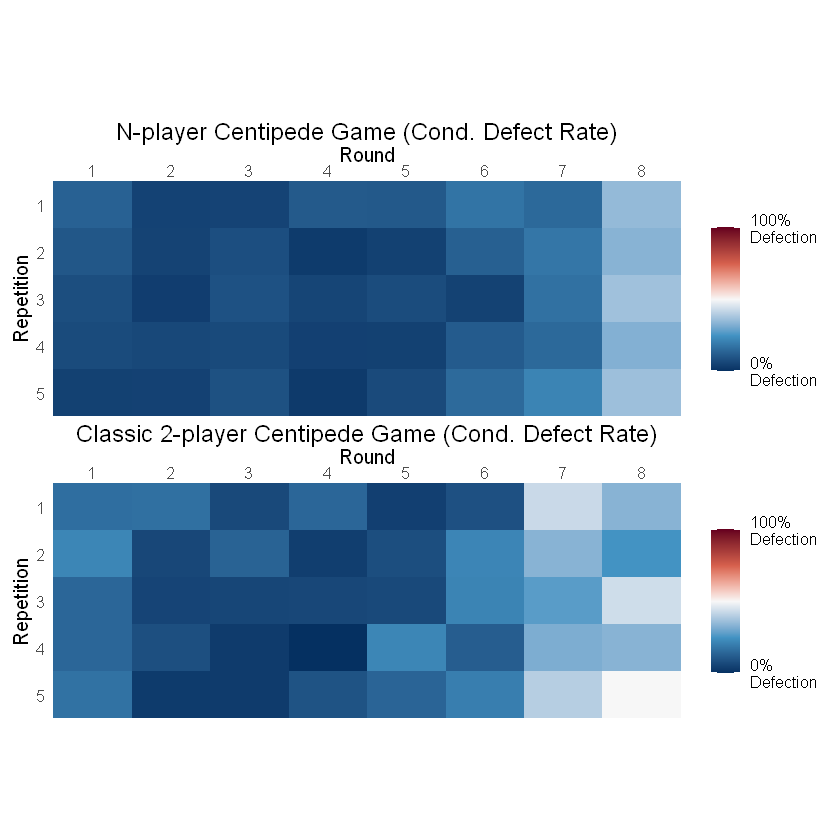

In [8]:
# =============================================================================
# =============================================================================
# 8.  XX-salin: OLD heatmap, cond. defect rate
# =============================================================================
# =============================================================================

##### Conditional Defect Rate Approach
# conditional proportion who defect at round N given reach round N

compute_heatmap_cond <- function(df, n_rounds = 8) {
  expand.grid(repetition = 1:5, node = 1:n_rounds) |>
    as_tibble() |>
    rowwise() |>
    mutate(
      reached  = sum(df$repetition == repetition & df$end_cat >= node),
      defected = sum(df$repetition == repetition & df$end_cat == node),
      defect_rate_cond = if_else(reached > 0, defected / reached, NA_real_)
    ) |>
    ungroup()
}

heatmap_8p_cond   <- compute_heatmap_cond(gnt_8p,   n_rounds = 8)
heatmap_2p8r_cond <- compute_heatmap_cond(gnt_2p8r, n_rounds = 8)

# plotting heatmaps

plot_heatmap_cond <- function(data, title) {
  ggplot(data, aes(x = node, y = repetition, fill = defect_rate_cond)) +
    geom_tile(linewidth = 0) +
    scale_fill_gradientn(
      colors  = rev(RColorBrewer::brewer.pal(11, "RdBu"))[c(1, 3, 6, 9, 11)],
      limits  = c(0, 1),
      breaks  = c(0, 1),
      labels  = c("0%\nDefection", "100%\nDefection"),
      name    = NULL
    ) +
    scale_x_continuous(breaks = 1:8, position = "top", expand = c(0,0)) +
    scale_y_continuous(breaks = 1:5, trans = "reverse", expand = c(0,0)) +
    labs(title = title, x = "Round", y = "Repetition") +
    coord_fixed(ratio = 0.6) +
    theme_minimal(base_size = 12) +
    theme(
      panel.grid      = element_blank(),
      plot.title      = element_text(hjust = 0.5, margin = margin(b=0)),
      legend.position = "right",
      axis.title.x.top = element_text(margin = margin(b=1, t = 0)),
      axis.text.x.top = element_text(margin = margin(b=2)),
      plot.margin = margin(2,2,2,2)
    )
}

p1cond <- plot_heatmap_cond(heatmap_8p_cond,   "N-player Centipede Game (Cond. Defect Rate)")
p2cond <- plot_heatmap_cond(heatmap_2p8r_cond, "Classic 2-player Centipede Game (Cond. Defect Rate)")

p1cond / p2cond

ggsave("heatmap_8p_cond.png", plot = p1cond, width = 6, height = 4, dpi = 300)
ggsave("heatmap_2p8r_cond.png", plot = p2cond, width = 6, height = 4, dpi = 300)

Infinite N-Player Centipede Games, Conditional Defection Rate Approach for heatmap -- same defection rate calc as barchart (in new data analysis)

In [ ]:
# NEW data setup

library(tidyverse)
library(patchwork)

processed  <- readRDS("NEWprocessed.rds")

######## defection by round 

summary_by_round <- processed %>%
  group_by(player.level) %>%
  summarise(
    n = n(),
    down = sum(player.choice == "Down"),
    right = sum(player.choice == "Right"),
    .groups = "drop"
  ) %>%
  mutate(
    pct_right = right / (down + right)
  ) %>%
  rowwise() %>%
  mutate(
    ci = list(prop.test(right, down + right)$conf.int)
  ) %>%
  mutate(
    ci_low = ci[[1]],
    ci_high = ci[[2]]
  ) %>%
  select(-ci)


# defection by round, barchart

#ggplot(summary_by_round, aes(x = player.level, y = pct_right, fill = pct_right)) +
#  geom_col(width = 0.8) +
#  geom_point(size = 3, color = "black") +
#  geom_errorbar(aes(ymin = ci_low, ymax = ci_high), width = 0.2, color = "black") +
#  labs(
#    x = "Round",
#    y = "Proportion of Defection (with 95% CI)",
#    title = "Defection by Round"
#  ) +
#  theme_minimal(base_size = 14) +
#  scale_y_continuous(limits = c(0, 1), breaks = seq(0, 1, 0.1)) +
#  scale_x_continuous(limits = c(0.6, 11.4), breaks = seq(1, 11, 1)) +
#  scale_fill_continuous_diverging("Blue-Red 3", mid = 0.5, limits = c(0, 1))


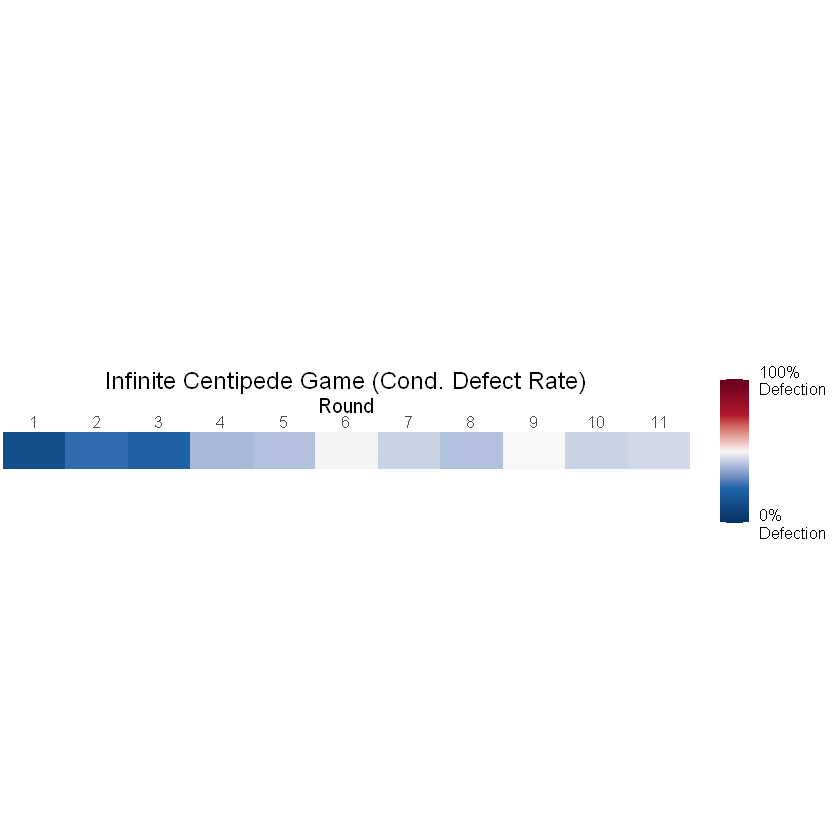

In [10]:
# =============================================================================
# =============================================================================
# 9.  XX-salin: NEW heatmap, cond. defect rate
# =============================================================================
# =============================================================================

##### Conditional Defect Rate Approach --> same as barchart
# conditional defection rate (proportion who defect at round N given reach round N)

heatmap_inf_cond <- processed |>
  group_by(player.level) |>
  summarise(
    down = sum(player.choice == "Down"),
    right = sum(player.choice == "Right"),
    .groups = "drop"
  ) |>
  mutate(defect_rate_cond = right / (down + right)) |>
  select(node = player.level, defect_rate_cond) |>
  mutate(repetition = 1)

# plotting heatmap

plot_heatmap_inf_cond <- function(data, title) {
  ggplot(data, aes(x = node, y = repetition, fill = defect_rate_cond)) +
    geom_tile(linewidth = 0) +
    scale_fill_gradientn(
      colors  = rev(RColorBrewer::brewer.pal(11, "RdBu"))[c(1, 2, 6, 10, 11)],
      limits  = c(0, 1),
      breaks  = c(0, 1),
      labels  = c("0%\nDefection", "100%\nDefection"),
      name    = NULL
    ) +
    scale_x_continuous(breaks = 1:11, position = "top", expand = c(0, 0)) +
    scale_y_continuous(expand = c(0, 0)) +
    labs(title = title, x = "Round", y = NULL) +
    theme_minimal(base_size = 12) +
    theme(
      panel.grid       = element_blank(),
      plot.title       = element_text(hjust = 0.5, margin = margin(b = 0)),
      legend.position  = "right",
      axis.title.x.top = element_text(margin = margin(b = 1, t = 0)),
      axis.text.x.top  = element_text(margin = margin(b = 2)),
      axis.text.y      = element_blank(),
      plot.margin      = margin(2, 2, 2, 2)
    ) +
    coord_fixed(ratio = 0.6)
}

p3cond <- plot_heatmap_inf_cond(heatmap_inf_cond, "Infinite Centipede Game (Cond. Defect Rate)")
p3cond

ggsave("heatmap_inf_cond.png", plot = p3cond, width = 6, height = 4, dpi = 300)